# To be able to edit and use this Notebook:

0. Learn about how to use google colaboratory [video](https://www.youtube.com/watch?v=inN8seMm7UI)
1. in the ```File``` menu (top left), click ```open in playground```
3. still in the ```File``` menu, click ```save copy in drive```, to make your own personalized and editable copy of this file. Alternatively you can ```open in playground mode```
4. edit as you like. If something breaks irreparably, either:
  1. restart the ```Runtime```
  2. or go back to step 1.


# Basic Modeling Neurons with Brian

This course makes use of the Brian 2 toolbox for modeling of neurons and neural networks. This assignment is aimed to take you by the hand as you  create a simple model of a changing membrane potential. After this assignment you will know the basic steps required to create a simple model using Brian 2.



# Learning objectives


After this project you will be able to:

* Understand what is a 'solver' of differential equations (particularly the Euler solver)
* Know how to simulate a model (a differential equation) in Brian 2 + python
* Understand the role of a time constant in an differential equation
* Control dynamically  the behaviour of a model via a voltage step
* Dynamically run the model and display its output


# Introduction and Key Terms

This assignment teaches you how to simulate a basic model with differential equations. This prepares you to understand the dynamics of the cellular membrane. This assignment also introduces some recurring terms of the modeling language. These terms are essential for the coming projects,  

* **Model**: a given representation of a phenomenon of choice. In computational modeling we often use differential equations to model a wide range of phenomena.
* **Differential equation**: an equation representing the rate of change in a given phenomenon.
* **State variable**: a variable that captures a given measurable in the system.
* **Simulation**: a computational procedure for obtaining solutions from a model.
* **Simulator**: a piece of software that produces the outcomes of a given model.
In the heart of the simulator we have a **solver**: a procedure (an algorithm) that simulates the model (i.e., it "solves" the differential equations).

## Brian 2

We will use the Brian 2 toolbox as our solver for Python for this project. The documentation of Brian 2 can be found [here](https://brian2.readthedocs.io/en/stable/user/index.html).


# Modeling change over time with differential equations

The creation of a computational model can be roughly summarized in two steps. First, we need to set up a differential equation based on the physical phenomenon of interest. For instance, let us consider a car driving at 20m/s. In a nutshell, a differential equation calculates the rate of change of a variable under observation, rather than the exact value of the variable. However, this rate of change can still be used to approximate the value of this variable.

The second step is to program the corresponding model. Say we want to know the distance that the car covers over the span of 100 seconds. One way to figure this out is by creating a linear equation that describes the position of the car over time. Alternatively, we could take the position of the car when we start measuring at t = 0s. Since we know that the car travels at 20 meters per second, we can find the position of the car at t = 1s by adding 20 meters to the position at t = 0. Then we can add another 20 meters to find the position at t = 2s, and so forth. In essence, this is how we use differential equations to approximate the value of a variable in the model.

The next segment will take you through these steps for modeling of the cell membrane potential ($V$). First, a simplified ordinary differential equation (ODE) is presented to estimate the change in membrane potential. Then you will write a model in Python based on this ODE.

The model takes two inputs: the resting potential (${V_{rest}}$) and an injected potential ($V_{in}$). The model aims to display how the membrane potential changes over time. It starts at the resting potential, then inserts the injected potential after 50ms and stabilizes again over time.

## Setting up the differential equation

The following mathematical formulas are important to determine the behavior of the model. Project 1 goes more into detail about each step.

A membrane has a potential called the driving force.

---


$$V - V_{rest}$$


---

The driving force is the difference between the membrane potential and the resting potential. A membrane is in a stable state when the driving force is equal to 0. The driving force determines whether the potential changes in a positive or negative direction, and determines the rate at which this happens.

The change in membrane potential (${\dot{V}}$) is also influenced by other factors, such as the capacitance of the membrane and the amount of gaps for ion exchange in the membrane (More in Projects 0 and 1). For now we will account for these factors by introducing an arbitrary constant $\tau$. Also note the sign change to make sure the direction is correct.

---

$$ \dot V = - \tau * (V-V_{rest}) $$

---

## Modeling and integration


In the previous equation we have found a way to calculate the membrane potential change per time unit. Next, we will introduce the **Euler method**. With this method we can calculate the membrane potential for the next time step (Note: ':=' means 'becomes').

---
$$ V := V + {\dot {V}} * dt $$

---

The model runs for a configurable amount of time $t$ in steps with a given length $dt$. It simply re-calculates the values of the variables in the system on every time step. In the exercises below, you'll see how this is done in Brian.

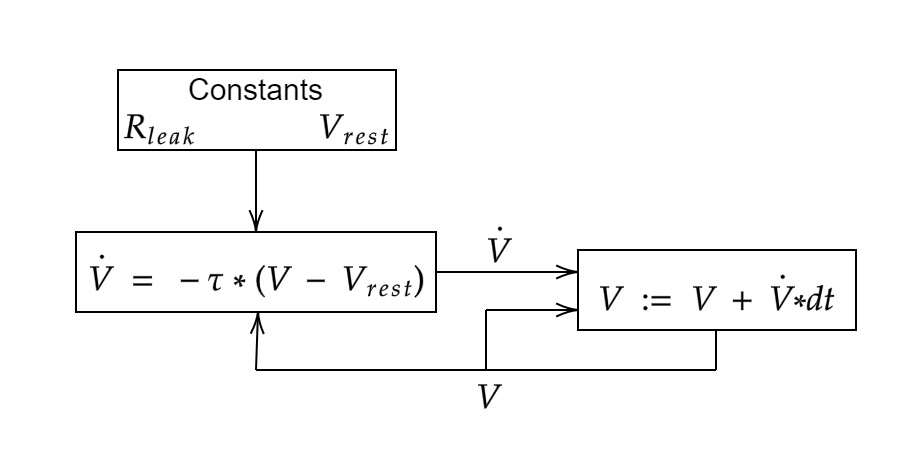

# Initialization code

In the code below, we import Brian 2 and any other relevant python modules. Run this code before starting the coding assigment.

In [1]:
# install brian2
!pip install brian2

# import necesary packages
from IPython.display import display
from brian2 import * # our simulator of choice
import brian2.numpy_ as np # the numpy that comes bundled with it
from ipywidgets import interact, interactive # for some neat interactions
from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt # for neat plots
import time # for time basis conversions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.6 MB/s eta 0:00:00


# Modeling the membrane

The script below provides a framework for the model. You're supposed to add the code in the right place according to the exercises. The code can be found below the exercises

# Exercises

1. Define the function RestingPotential with input argument V_in. Write down 'return' on the bottom of the function to mark the end of RestingPotential. The bounds of the function are indicated by the lines of hashtags.

2. Add tau as a constant to the RestingPotential function, with a value equal to 1/10. Additionally, define the resting potential V_rest in the function and set it equal to 0.
  
  1. Brian 2 requires us to submit the units of each variable in the model. We will ignore these units for now. But in order not to confuse Brian, we have to define the unit of tau. Tau is a time constant, effectively 'parts per second', so it has the unit of frequency (Hz, or $ ms^{-1} $). To be consistent, we have to add ```* msecond ** -1``` as the unit of tau, at the end of the line in which tau is defined. (note: remember that exponentiation in python is written as **).

3. Below the function. Using the command ```interactive``` from project zero, create a slider for V_in. Store the slider in variable ```I```. Let its values range between -50.0 and 50.0. Use the command ```display(I)``` to make the slider visible when running the code.

4. Add the formula for $\dot{V}$ to variable ```eqs```. Name the variable ```dv/dt```
  1. The formula is passed to Brian as a string. The formulas can be entered between the quotation marks just like you would enter them in normal Python code.
  2. Brian 2 requests us to add the units of the variables after a colon at the end of the line. We will use dummy units for now. ```: 1``` at the end of the line accounts for this

In the next lines of code, the model is set up.

* First, a neuron group ```G``` consisting of 1 neuron is created. Its behaviour is defined in variable ```eqs```. The third argument ```'euler'``` specifies how the charge is integrated on each timestep. Brian automatically performs the step    $ V := V + {\dot {V}} * dt$    .
* Next, a StateMonitor ```M``` is created. It monitors neuron group ```G```, specifically variable ```v```.
* On the next step, the value ```v``` of neuron group ```G``` is initialized and set to ```V_rest```
* Last, the model is run for 50 milliseconds.
<br><br>

5. Now we want to add the voltage injection $V_{in}$ to the model. We can do this simply by setting the value of ```v``` in neuron group ```G``` to ```V_in```, similar to the code above. Run the code an additional 100ms.

6. All that's left to do now is to display the membrane potential during the simulation.
  
  1. Start by writing ```axes = plt.gca()``` to create the figure.
  2. Use the command ```plt.plot(x,y)``` to plot the data. Variables x and y are vectors that hold the values of each datapoint's respective x and y values. Since we want to plot potential over time, we want time on the x-axis and potential on the y-axis. The time in milliseconds is stored in ```M.t/ms```. The potential of the one neuron in the group is stored in ```M.v[0]/mV```.
  3. We can set the ranges of the x-axis and the y-axis between two values a and b using ```plt.xlim(a,b)``` and ```plt.ylim(a,b)```. Make sure the time axis ranges between 0 and 150ms and that the vertical axis is fixed between -50 and 50 mV.
  4. Lastly, add labels to the axes using the commands ```plt.xlabel('label')``` and ```plt.ylabel('label')```.

7. Now run the model. Can you explain what is happening?
8. Bonus 1: check out what happens when you change the value of tau.
9. Bonus 2: can you figure out how to configure the IS units of the model? Hint: 'mV' and 'volt' are the respective IS units and Brian units you will need.

In [ ]:
################################################################################
# Exercise 1 - Define the function RestingPotential in the line below.
def MyFunction(arg)
# This function displays the changing membrane potential over time given
# an input voltage V_in

    # start_scope()

    # Adjust input variables for scale (milli)
    V_in = V_in / 1000

    # Exercise 2 - Define constants
    # ...                                                       * msecond ** -1

    # Exercise 4 - Define equations that should be passed to the model.
    # Note 1: Brian requests these equations as a string. The equations can be
    #         entered between the apostrophes in default Python syntax.
    # Note 2: The unit of the variable must be specified behind a colon at
    #         the end of the line, given as a 'base unit' of the ISU. We will
    #         ignore these for now and add ' : 1' instead
    # eqs = " some formula : 1"
    eqs= "  "

    # Create a neuron group G with 1 neuron, the specified equations and euler
    # integration method
    G = NeuronGroup(1, eqs, 'euler')

    # introduce a StateMonitor in G to record the membrane potential
    M = StateMonitor(G, ['v'], record=0)

    # Run first 50ms at resting potential
    G.v = V_rest
    run(50*ms)

    # Exercise 5 - Set the membrane potential of the neuron group to the
    # injected current V_in and run the model for another 100ms


    # Exercise 6 - Plot the output of the function


    # Exercise 1 - End the function
    return

################################################################################

# Exercise 3 - Use 'interactive' to create sliders for 'V_in' and display them
# using 'display'



SyntaxError: ignored

# Answer


In [ ]:
# Define the function FindCurrentChange

def RestingPotential(V_in):
    start_scope()
    # This function displays the changing membrane potential over time given
    # an input voltage V and a resting potential V_rest

    # Divide input variables by 1000 to adjust for the scale (milli)
    V_in = V_in * mV

    # Define constants
    V_rest = 0 * mV
    tau = 1/10 * msecond ** -1

    # Define equations that should be passed to the model.
    # Note 1: Brian requests these equations as a string. The equations can be
    #         entered between the apostrophes in default Python syntax.
    # Note 2: The unit of the variable must be specified behind a semicolon at
    #         the end of the line, given as a 'base unit' of the ISU.
    eqs = '''
        dv/dt = - tau * (v - V_rest) : volt
    '''

    # Create a neuron group G with 1 neuron, the specified equations and euler
    # integration method
    G = NeuronGroup(1, eqs, 'euler')


    # introduce a StateMonitor in G to record variable 'v'
    M = StateMonitor(G, ['v'], record=0)

    # run first 50ms at resting potential
    G.v = V_rest
    run(50*ms)

    # Set voltage to value of the clamp V_in
    G.v = V_in

    # Run the model for another 100 milliseconds
    run(100*ms)

    # Plot the output of the function
    axes = plt.gca()
    plt.plot(M.t/ms, M.v[0]/mV)
    plt.xlabel('Time (ms)')
    plt.ylabel('V (mV)')
    plt.xlim(0,150)
    plt.ylim(-50,50)


    # End the function
    return


# Use 'interactive' to create sliders for 'V' and 'V_rest'
I = interactive(RestingPotential, V_in=(-50.,50.))

display (I)


interactive(children=(FloatSlider(value=0.0, description='V_in', max=50.0, min=-50.0), Output()), _dom_classes…

Exploration: add the ability to control the value of tau to your interactive function. What happens when you change tau?